In [1]:
from gen_umap_emb import GenerateUmapEmb
from gen_hdb_clus import GenerateHDBSCAN
from pathlib import Path
import pandas as pd
import sys
import hdbscan

import numpy as np
from gen_hdb_clus import GenerateHDBSCAN

ROOT = Path('/Users/josh/Library/CloudStorage/GoogleDrive-jeverer@gmail.com/My Drive/London Sport/london_sport2')

df_path = ROOT / 'exploration' / 'data' / 'master_data' / '2016_to_2023_master_clustering_data_set.csv'
df = pd.read_csv(df_path)

sys.path.append(str(ROOT / 'src' / 'stream_1' / 'forecasting'))
from forecasting_tools import prophet_forecast, plot_borough_forecasts, plot_cluster_forecasts

/opt/anaconda3/envs/london/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
df_lca = pd.read_csv(ROOT / 'exploration' / 'data' / 'master_data' / 'latent_class_forecasting_data_set.csv')
df_lca_annual = df_lca[['LCA_Class', 'year', 'Mean_MEMS7_ALL']].rename(columns={'Mean_MEMS7_ALL': 'MEMS7_ALL'})
df_lca_annual['year'] = df_lca_annual['year'].str.split('/').str[1].astype(int) + 2000
results_lca = prophet_forecast(df_lca_annual, t_train_cutoff=5, forecast_steps=6, group_col='LCA_Class')
print(np.mean(results_lca['mape']))

09:41:28 - cmdstanpy - INFO - Chain [1] start processing
09:41:28 - cmdstanpy - INFO - Chain [1] done processing
09:41:28 - cmdstanpy - INFO - Chain [1] start processing
09:41:28 - cmdstanpy - INFO - Chain [1] done processing
09:41:28 - cmdstanpy - INFO - Chain [1] start processing
09:41:28 - cmdstanpy - INFO - Chain [1] done processing
09:41:28 - cmdstanpy - INFO - Chain [1] start processing
09:41:28 - cmdstanpy - INFO - Chain [1] done processing
09:41:28 - cmdstanpy - INFO - Chain [1] start processing
09:41:28 - cmdstanpy - INFO - Chain [1] done processing
09:41:28 - cmdstanpy - INFO - Chain [1] start processing
09:41:28 - cmdstanpy - INFO - Chain [1] done processing
09:41:29 - cmdstanpy - INFO - Chain [1] start processing
09:41:29 - cmdstanpy - INFO - Chain [1] done processing
09:41:29 - cmdstanpy - INFO - Chain [1] start processing
09:41:29 - cmdstanpy - INFO - Chain [1] done processing
09:41:29 - cmdstanpy - INFO - Chain [1] start processing
09:41:29 - cmdstanpy - INFO - Chain [1]

18.213282341337067


In [3]:
df_lca_quarterly = df[df['LCA_Class'].notna()].copy()
df_lca_quarterly['year'] = df_lca_quarterly['year'].str.split('/').str[1].astype(int) + 2000
df_lca_quarterly['month'] = ((df_lca_quarterly['month'].astype(int) - 3) % 12) + 1
df_lca_quarterly['quarter'] = pd.cut(df_lca_quarterly['month'], bins=[0,3,6,9,12], labels=[1,2,3,4])

df_lca_quarterly = df_lca_quarterly.groupby(['LCA_Class', 'year', 'quarter']).agg(
    MEMS7_ALL=('MEMS7_ALL', 'mean')
).reset_index()

results_lca_q = prophet_forecast(df_lca_quarterly, t_train_cutoff=20, forecast_steps=20, group_col='LCA_Class')
print(np.mean(results_lca_q['mape']))

09:41:32 - cmdstanpy - INFO - Chain [1] start processing
09:41:32 - cmdstanpy - INFO - Chain [1] done processing
09:41:32 - cmdstanpy - INFO - Chain [1] start processing
09:41:32 - cmdstanpy - INFO - Chain [1] done processing
09:41:32 - cmdstanpy - INFO - Chain [1] start processing
09:41:32 - cmdstanpy - INFO - Chain [1] done processing
09:41:32 - cmdstanpy - INFO - Chain [1] start processing
09:41:32 - cmdstanpy - INFO - Chain [1] done processing
09:41:32 - cmdstanpy - INFO - Chain [1] start processing
09:41:32 - cmdstanpy - INFO - Chain [1] done processing
09:41:32 - cmdstanpy - INFO - Chain [1] start processing
09:41:32 - cmdstanpy - INFO - Chain [1] done processing
09:41:32 - cmdstanpy - INFO - Chain [1] start processing
09:41:32 - cmdstanpy - INFO - Chain [1] done processing
09:41:32 - cmdstanpy - INFO - Chain [1] start processing
09:41:32 - cmdstanpy - INFO - Chain [1] done processing
09:41:32 - cmdstanpy - INFO - Chain [1] start processing
09:41:32 - cmdstanpy - INFO - Chain [1]

24.792553314979806


---------------------------
----- YEARLY FORECAST -----
---------------------------


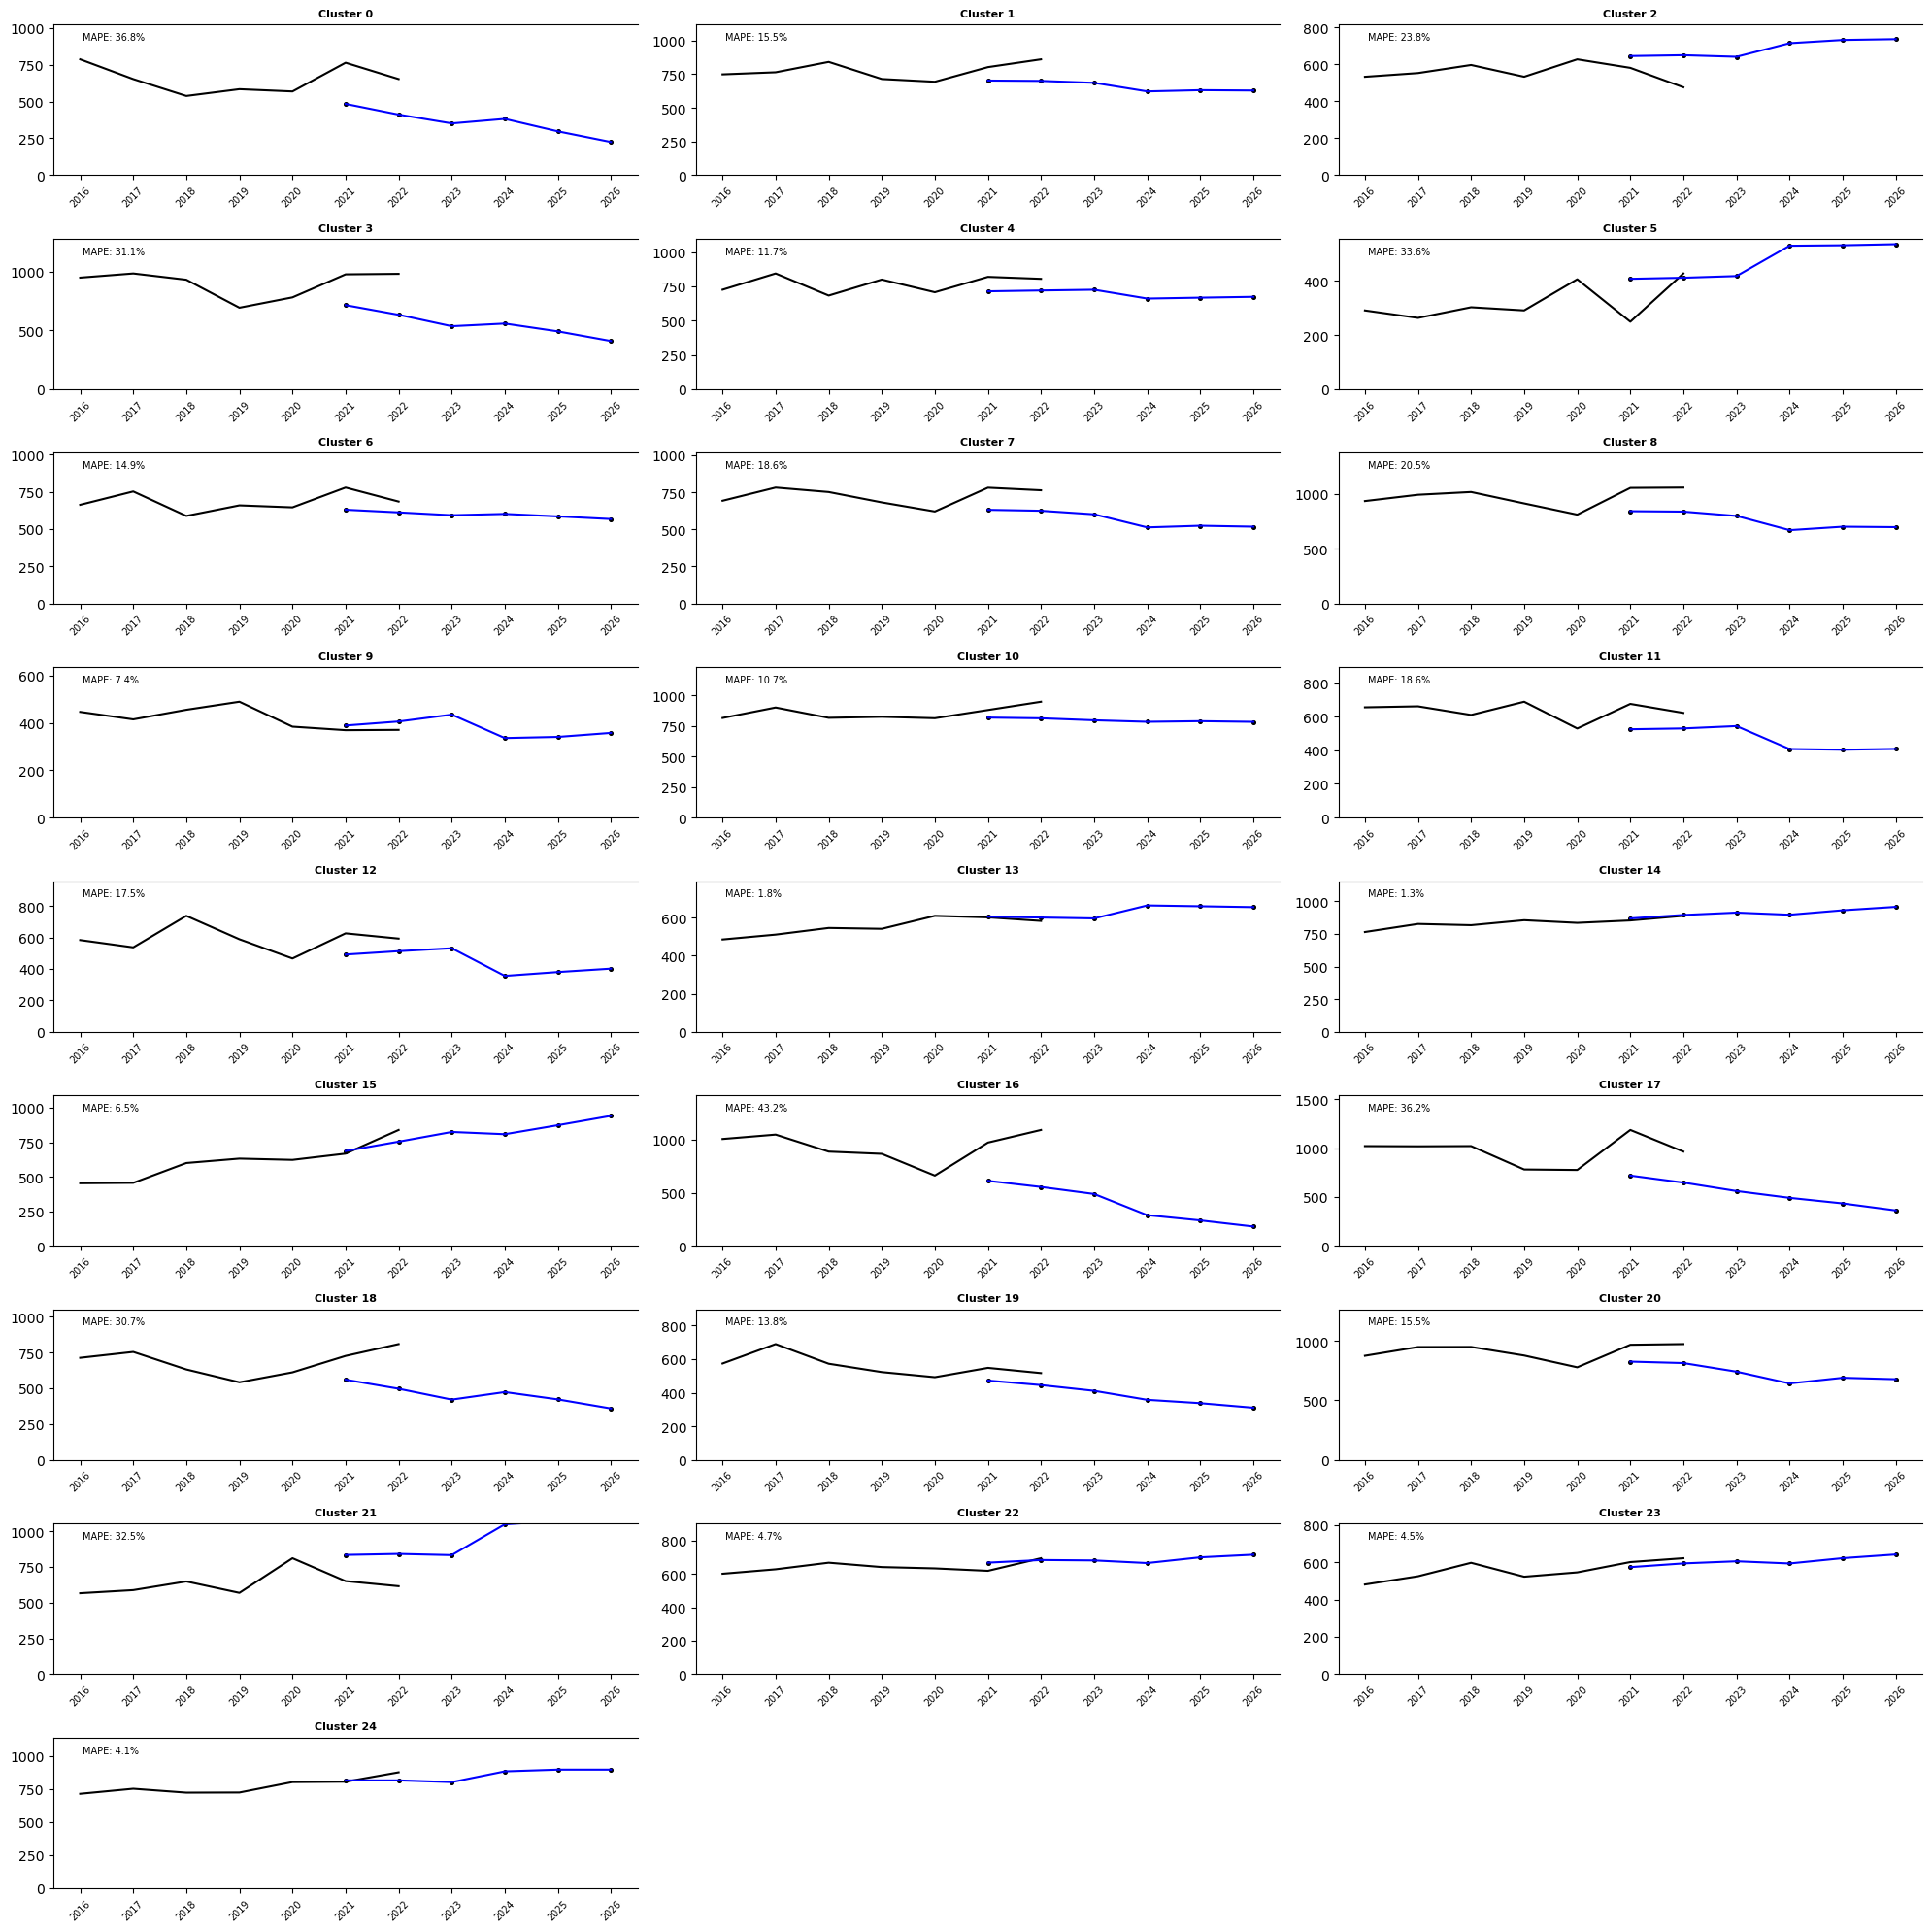

In [ ]:
print("---------------------------")
print("----- YEARLY FORECAST -----")
print("---------------------------")
print(np.mean(results_lca['mape']))
xtick_positions = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
xtick_labels = ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
plot_cluster_forecasts(results_lca, t_train_cutoff=5, xtick_positions=xtick_positions, xtick_labels=xtick_labels, group_col='LCA_Class', UNCERTAINTY=True)

------------------------------
----- QUARTERLY FORECAST -----
------------------------------


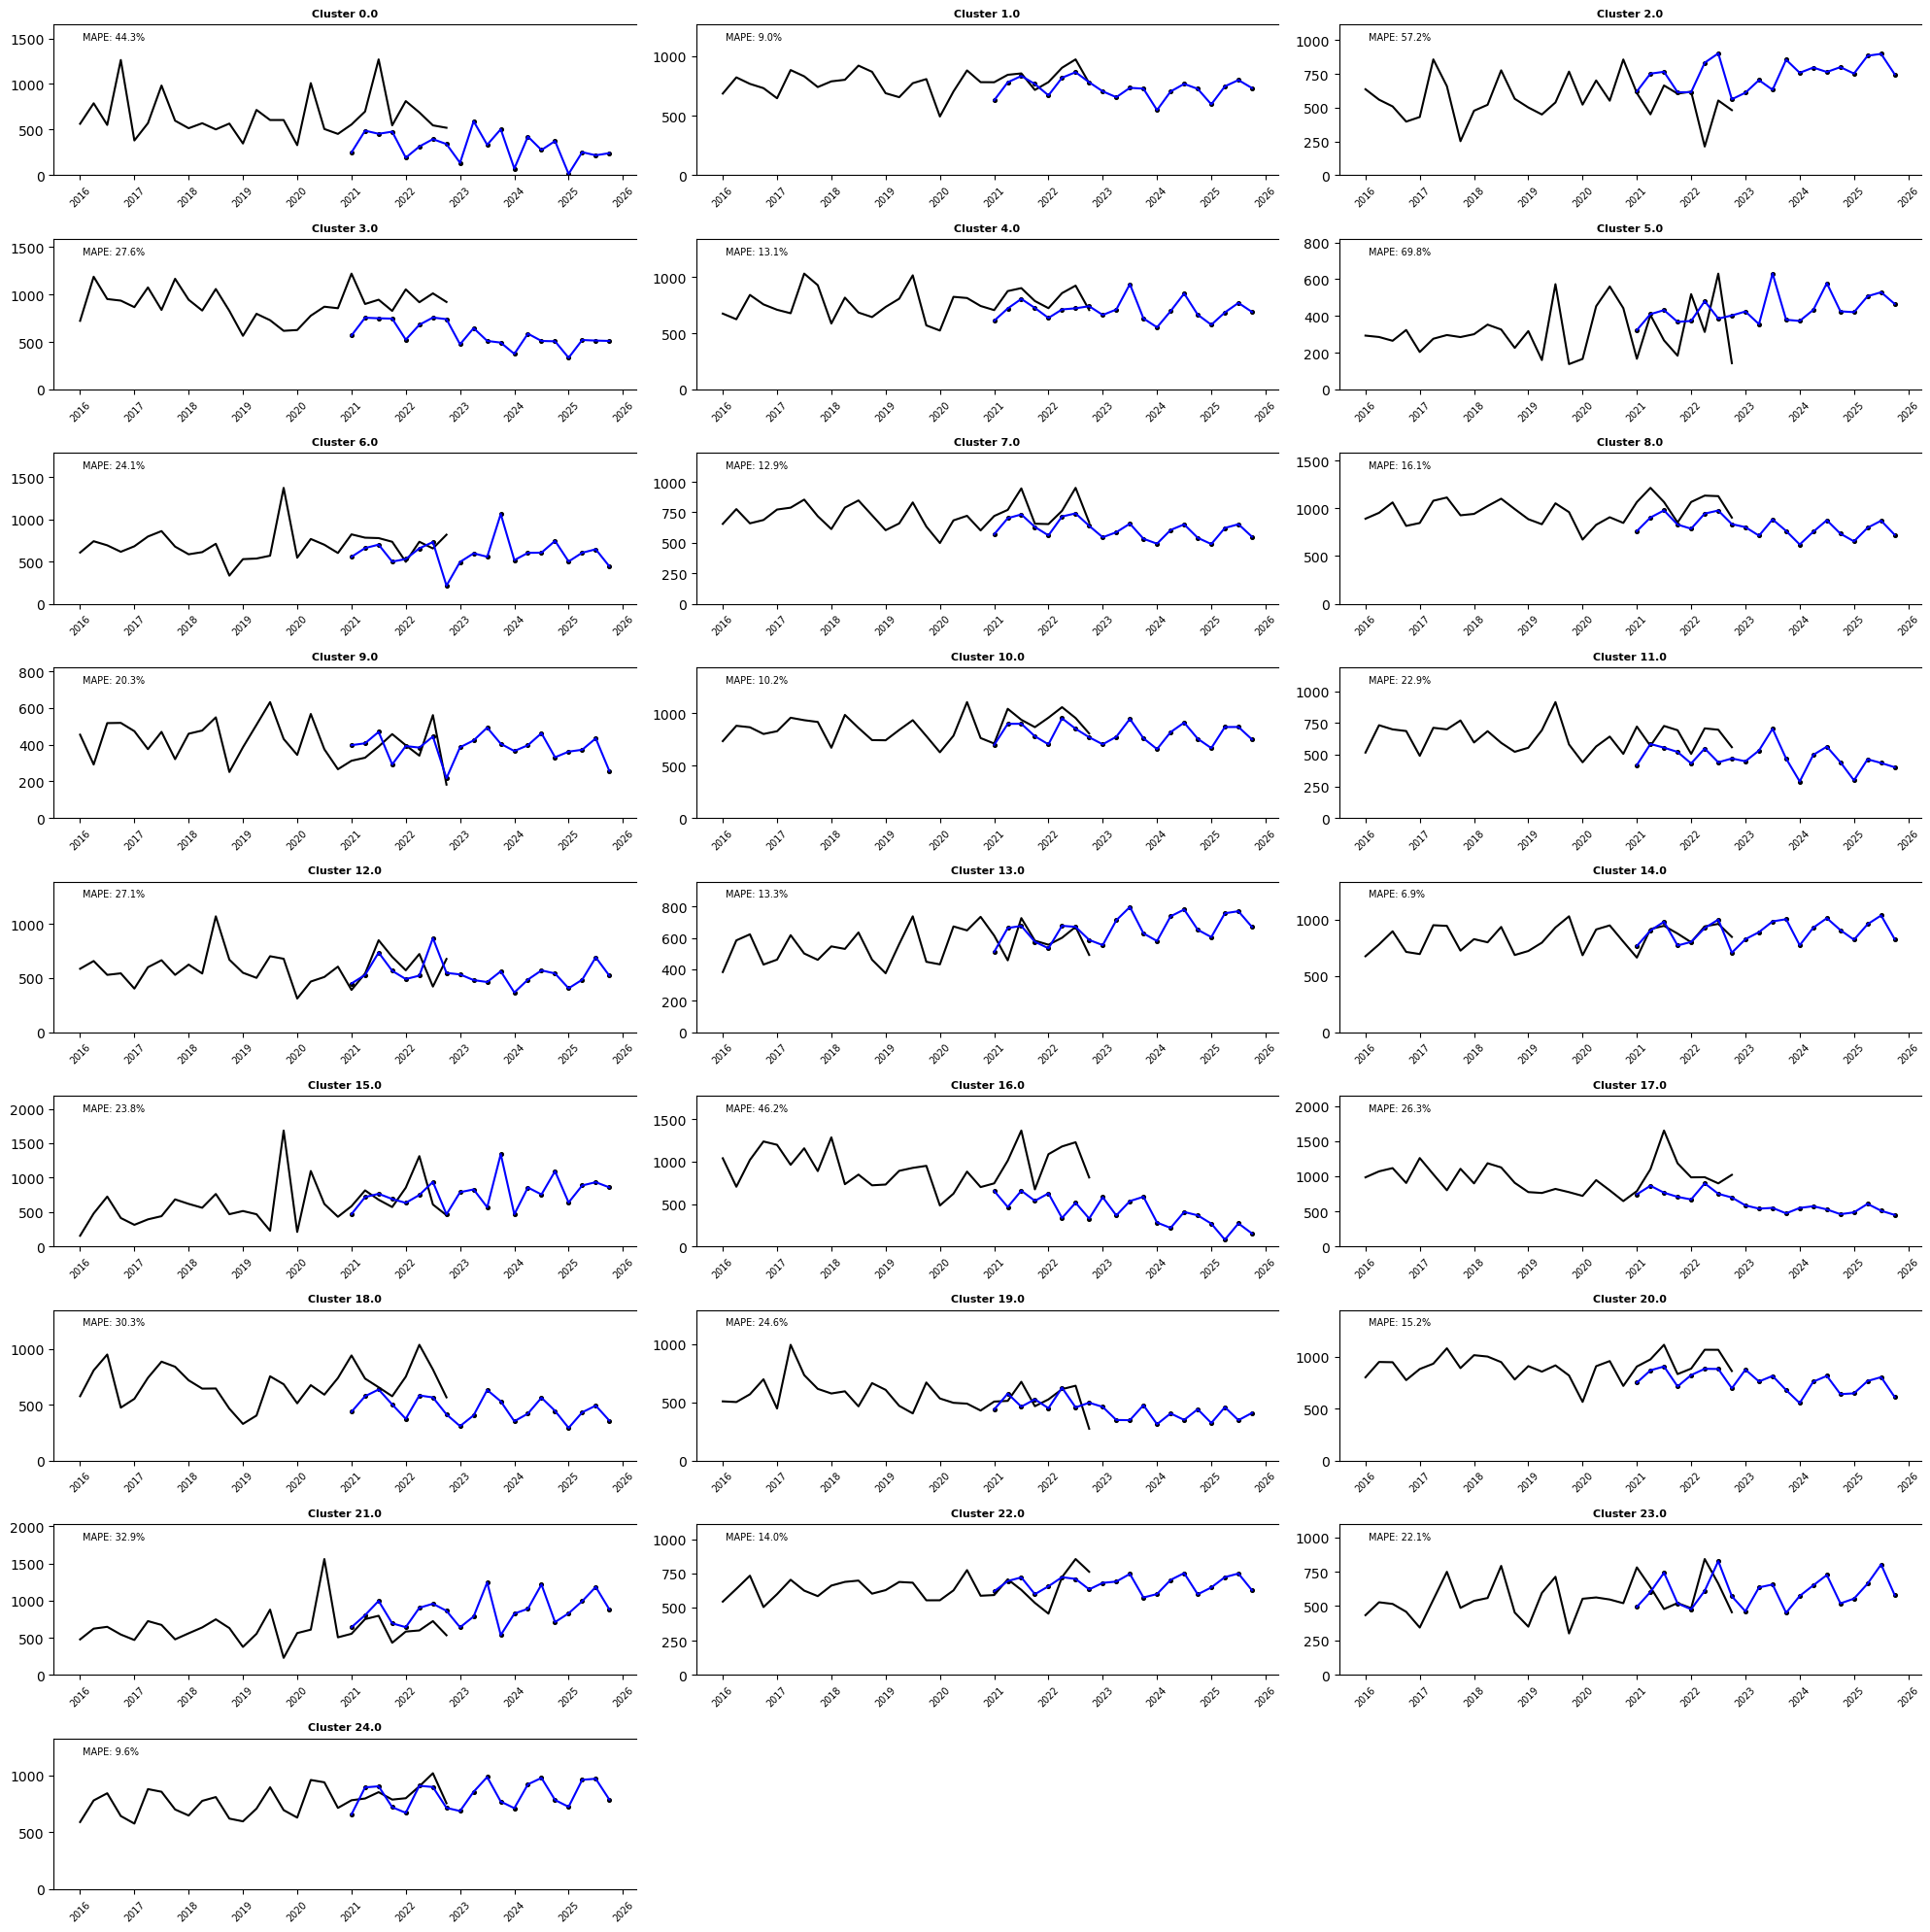

In [ ]:
print("------------------------------")
print("----- QUARTERLY FORECAST -----")
print("------------------------------")
print(np.mean(results_lca_q['mape']))
xtick_positions = [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40]
xtick_labels = ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
plot_cluster_forecasts(results_lca_q, t_train_cutoff=20, xtick_positions=xtick_positions, xtick_labels=xtick_labels, group_col='LCA_Class', UNCERTAINTY=True)

In [9]:
from forecasting_tools import tune_sarima

results_sarima = tune_sarima(df_lca_quarterly, t_train_cutoff=20, forecast_steps=20, group_col='LCA_Class')
print(np.mean(results_sarima['mape']))

-------------------------
----- TUNING SARIMA -----
-------------------------


  4%|▍         | 1/25 [00:00<00:07,  3.05it/s]

0.0: (0, 0, 0) x (0, 1, 0, 4)


  8%|▊         | 2/25 [00:00<00:07,  3.13it/s]

1.0: (0, 0, 0) x (0, 1, 0, 4)


...

22.0: (0, 0, 0) x (0, 1, 0, 4)


 96%|█████████▌| 24/25 [00:10<00:00,  2.74it/s]

23.0: (0, 0, 0) x (0, 1, 0, 4)


100%|██████████| 25/25 [00:12<00:00,  1.94it/s]

24.0: (2, 0, 2) x (2, 1, 1, 4)
23.230478133587216


-------------------------------------
----- QUARTERLY SARIMA FORECAST -----
-------------------------------------


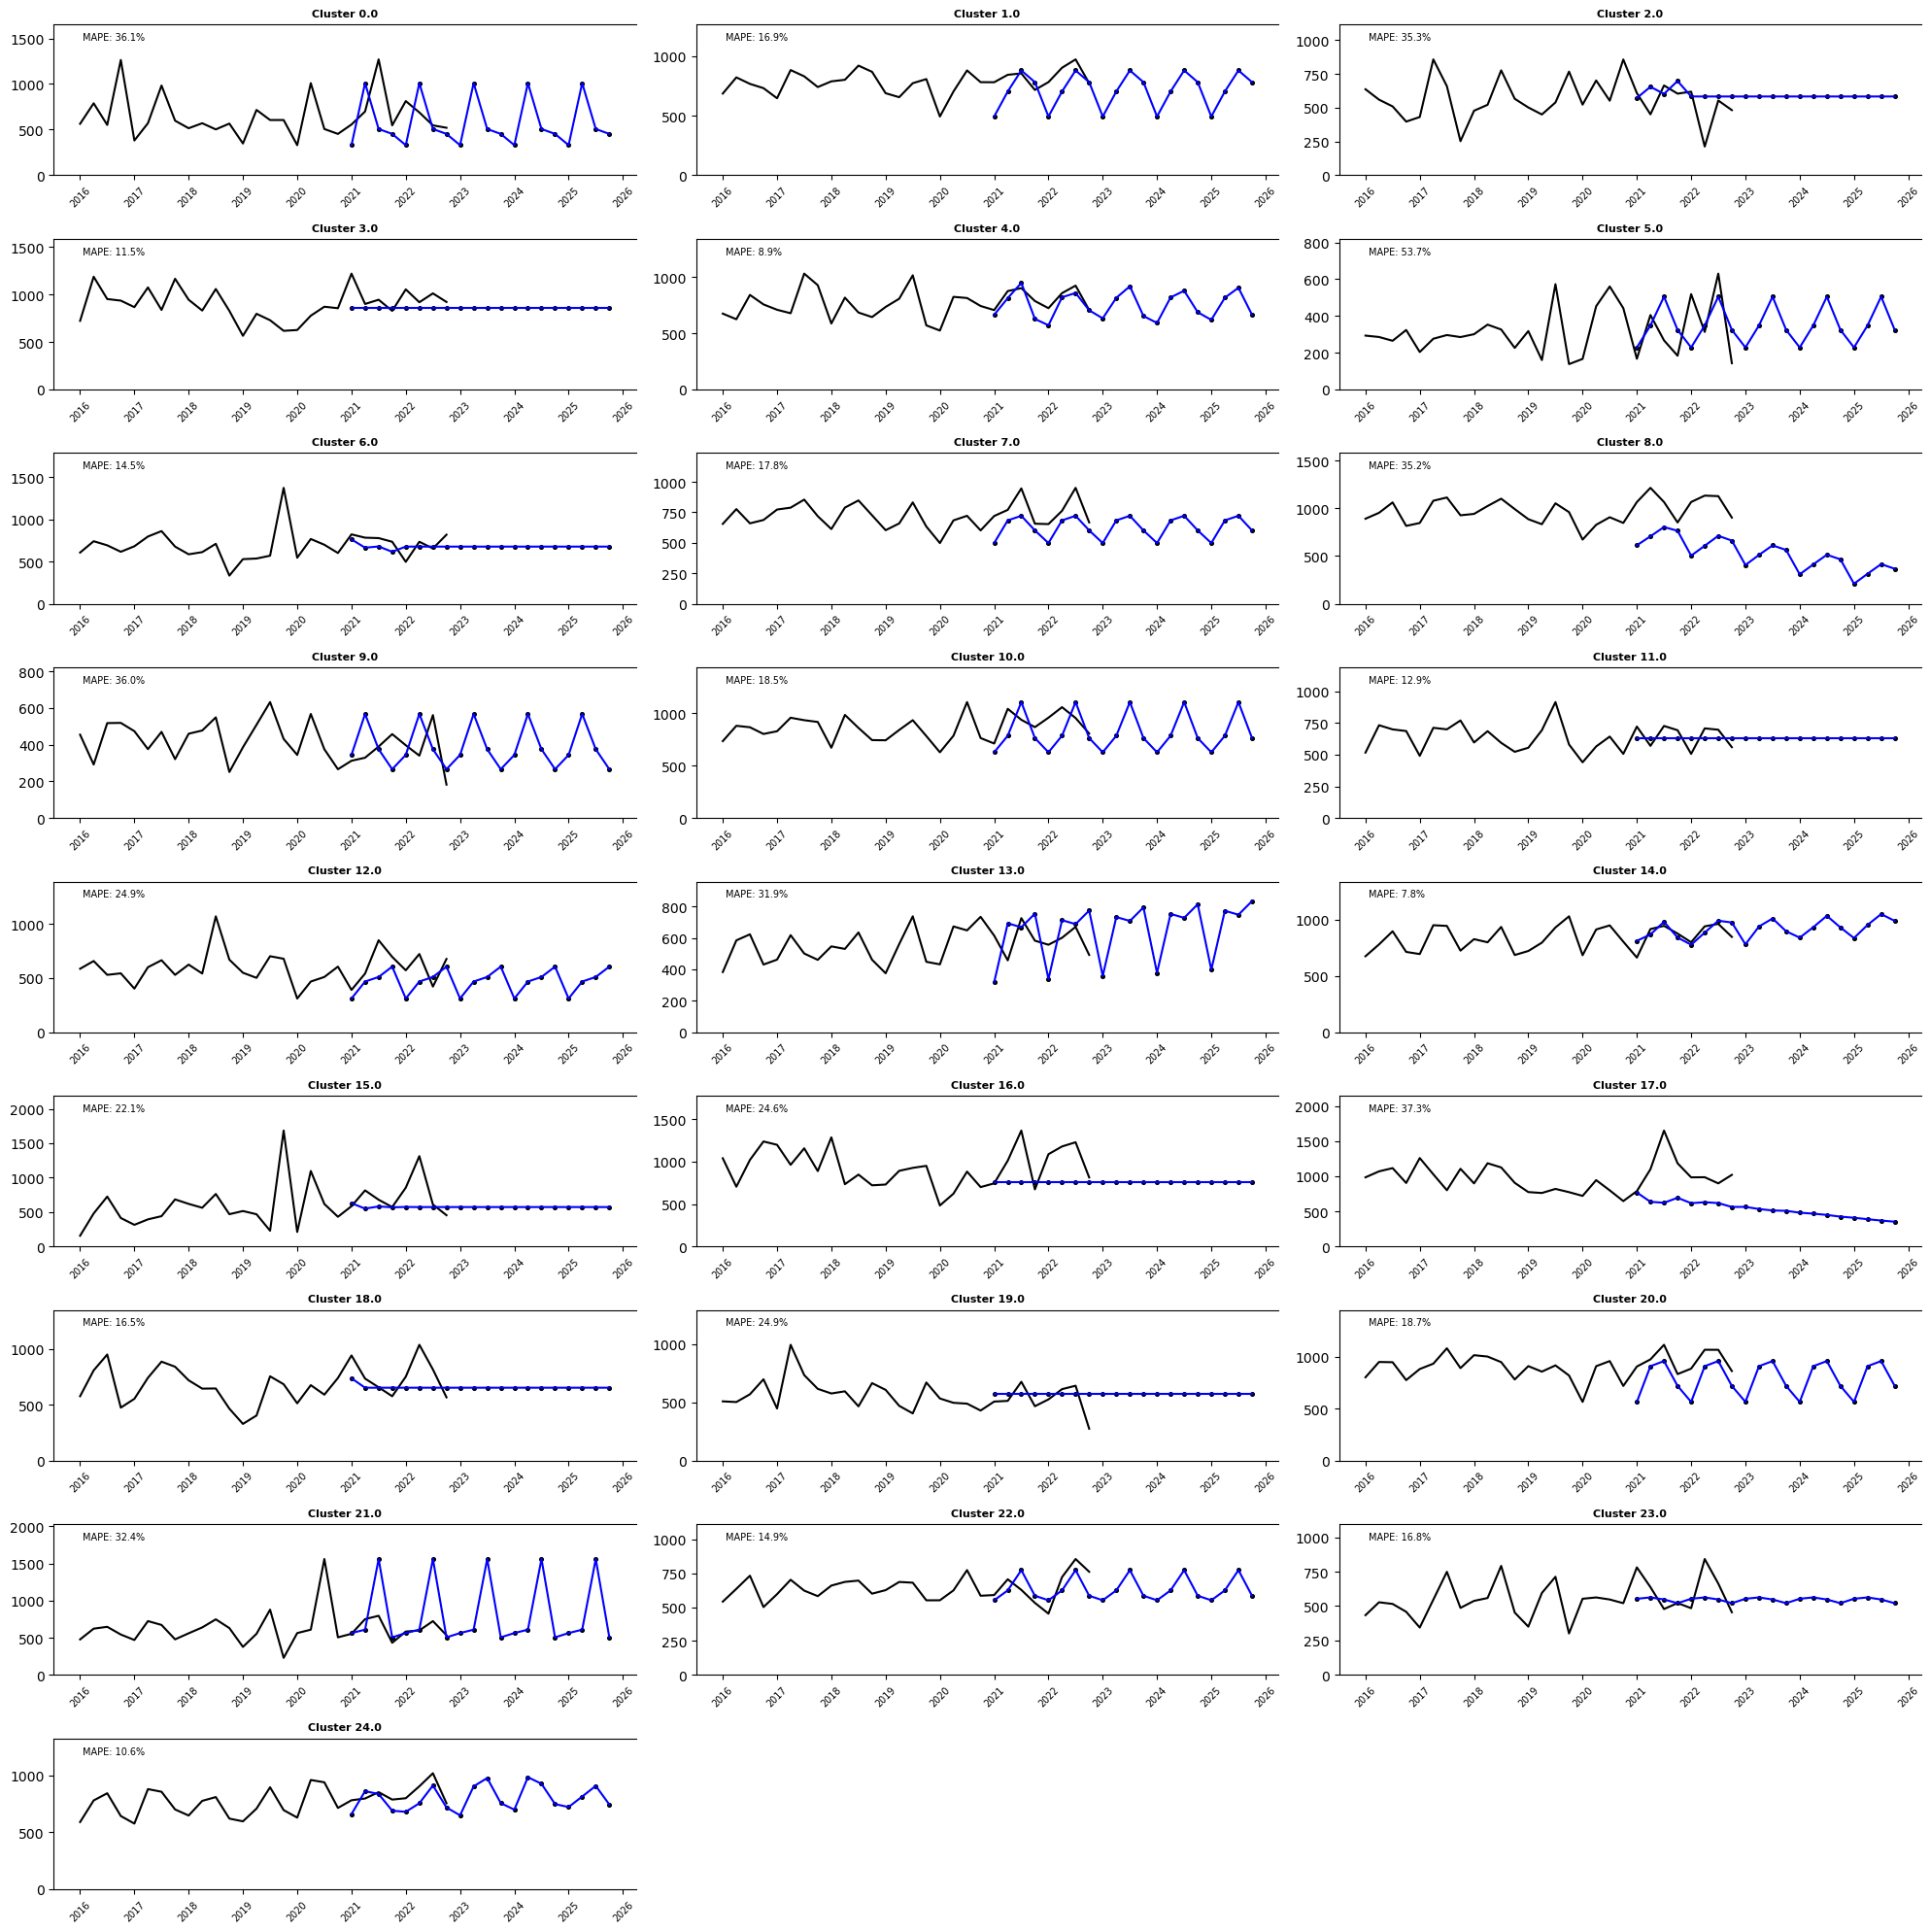

In [ ]:
print("-------------------------------------")
print("----- QUARTERLY SARIMA FORECAST -----")
print("-------------------------------------")
print(np.mean(results_sarima['mape']))
xtick_positions = [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40]
xtick_labels = ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
plot_cluster_forecasts(results_sarima, t_train_cutoff=20, xtick_positions=xtick_positions, xtick_labels=xtick_labels, group_col='LCA_Class')